In [46]:
import pandas as pd
import numpy as np

df_students = pd.read_csv('grades.csv')

In [56]:
df_students

,Name,StudyHours,Grade,Passed
0,Dan,10.00,50.0,False
1,Joann,11.50,50.0,False
2,Pedro,9.00,47.0,False
3,Rosie,16.00,97.0,True
4,Ethan,9.25,49.0,False
5,Vicky,1.00,3.0,False
6,Frederic,11.50,53.0,False
7,Jimmie,9.00,42.0,False
8,Rhonda,8.50,26.0,False
9,Giovanni,14.50,74.0,True


In [12]:
# find missing values and remove them
df_students.isnull().sum()

Name          0
StudyHours    0
Grade         0
dtype: int64

In [7]:
# replace StudyHours missing values with the mean
df_students.StudyHours = df_students.StudyHours.fillna(df_students.StudyHours.mean())

In [48]:
# remove rows with missing values in the Grade column
df_students = df_students.dropna(axis=0)

In [15]:
# calculate average study hours and average grade
mean_study = df_students.StudyHours.mean()
mean_grade = df_students.Grade.mean()
print(f'Average weekly study hours: {mean_study:.2f}')
print(f'Average grade: {mean_grade:.2f}')

Average weekly study hours: 10.52
Average grade: 49.18


In [20]:
# find students who study more than the average and have a grade above the average
df_students[df_students.StudyHours > mean_study]

,Name,StudyHours,Grade,Passed
1,Joann,11.50,50.0,False
3,Rosie,16.00,97.0,True
6,Frederic,11.50,53.0,False
9,Giovanni,14.50,74.0,True
10,Francesca,15.50,82.0,True
11,Rajab,13.75,62.0,True
14,Jenny,15.50,70.0,True
19,Skye,12.00,52.0,False
20,Daniel,12.50,63.0,True
21,Aisha,12.00,64.0,True


In [18]:
# calculate the average grade for students who study more than the average
df_students[df_students.StudyHours > mean_study].Grade.mean()

np.float64(66.7)

In [55]:
# create a new column 'Passed' that indicates whether the student passed (grade >= 60)
passed = pd.Series(df_students.Grade >= 60)

df_students = pd.concat([df_students, passed.rename('Passed')], axis=1)

In [25]:
# count how many students passed and how many failed
df_students.groupby(df_students.Passed).Name.count()

Passed
False    15
True      7
Name: Name, dtype: int64

In [35]:
# calculate the average study hours and average grade for students who passed and for those who failed
df_students.groupby(df_students.Passed)[['StudyHours', 'Grade']].mean()

,StudyHours,Grade
Passed,,
False,8.783333,38.000000
True,14.250000,73.142857


In [ ]:
# sort students by grade
# df_students = df_students.sort_values(by='Grade')
# sort students by study hours
df_students = df_students.sort_values(by='StudyHours', ascending=False)

/var/folders/y3/wkpj6zv13tv6m566htln9m1h0000gn/T/ipykernel_20114/3062018915.py:11: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


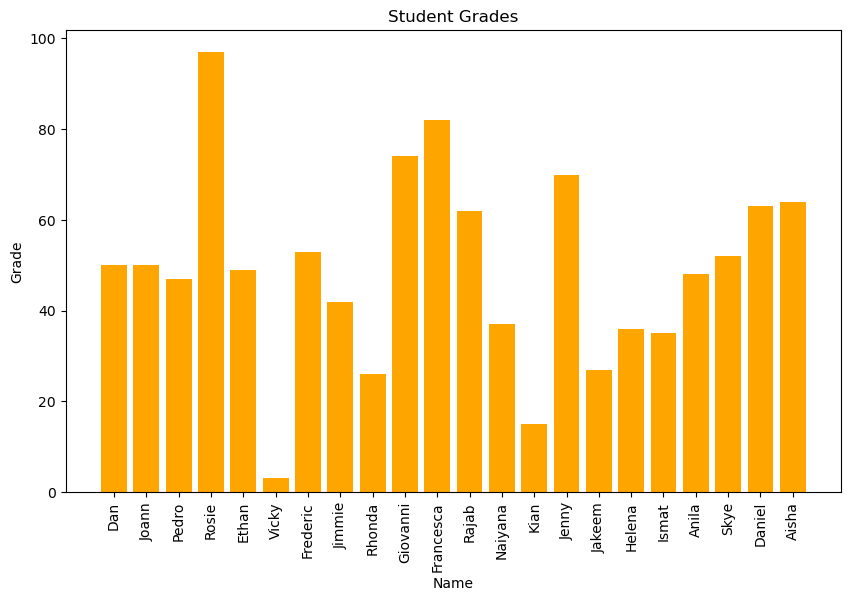

In [75]:
# visualize the grades of the students using a bar chart
from matplotlib import pyplot as plt

fig = plt.figure(figsize=(10, 6))
plt.bar(x=df_students.Name, height=df_students.Grade, color='orange')
plt.title('Student Grades')
plt.xlabel('Name')
plt.ylabel('Grade')
plt.xticks(rotation=90)

fig.show()

/var/folders/y3/wkpj6zv13tv6m566htln9m1h0000gn/T/ipykernel_20114/2298880171.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[0].set_xticklabels(df_students.Name, rotation=90)
/var/folders/y3/wkpj6zv13tv6m566htln9m1h0000gn/T/ipykernel_20114/2298880171.py:13: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


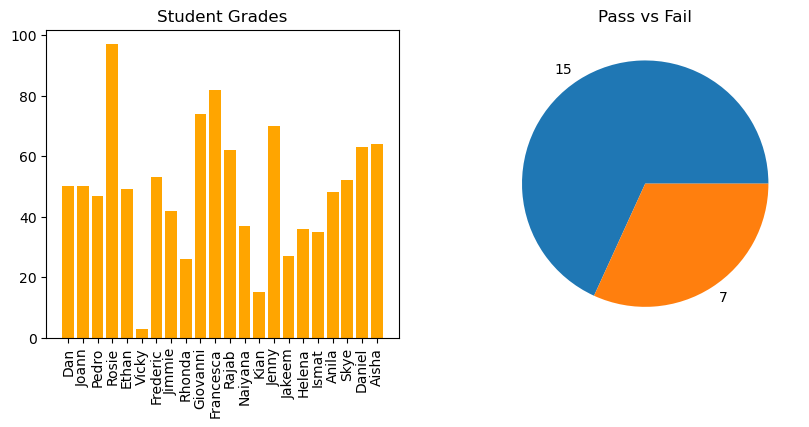

In [74]:
# visualize the distribution of grades using a histogram
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
ax[0].bar(x=df_students.Name, height=df_students.Grade, color='orange')
ax[0].set_title('Student Grades')
ax[0].set_xticklabels(df_students.Name, rotation=90)

# visualize the distribution of passes and fails using a pie chart
passes_count = df_students.Passed.value_counts()

ax[1].pie(passes_count, labels=passes_count)
ax[1].set_title('Pass vs Fail')

fig.show()

<Axes: xlabel='Name'>

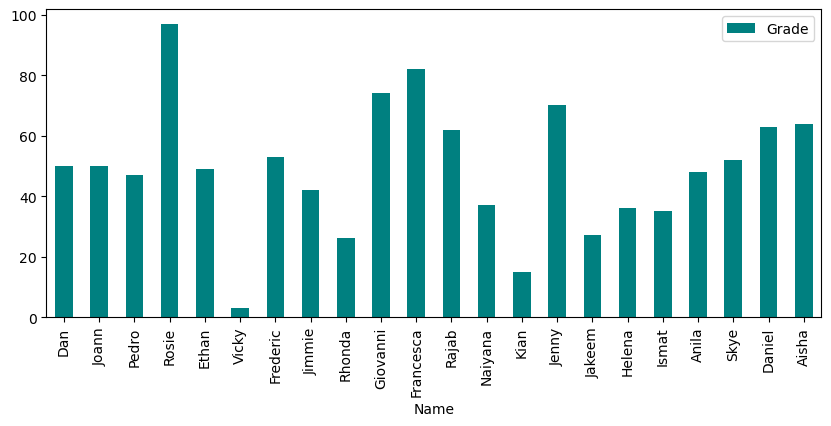

In [76]:
df_students.plot.bar(x='Name', y='Grade', color='teal', figsize=(10, 4))

Min: 3.00
Max: 97.00
Mean: 49.18
Median: 49.50
Mode: 50.00


/var/folders/y3/wkpj6zv13tv6m566htln9m1h0000gn/T/ipykernel_20114/149768546.py:29: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


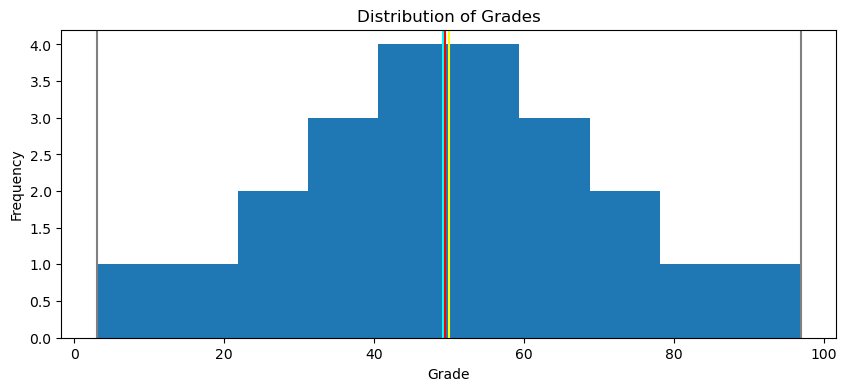

In [66]:
# visualize the distribution of grades using a histogram
grades = df_students.Grade

min_val = grades.min()
max_val = grades.max()
mean_val = grades.mean()
med_val = grades.median()
mode_val = grades.mode()[0]

print(f'Min: {min_val:.2f}')
print(f'Max: {max_val:.2f}')
print(f'Mean: {mean_val:.2f}')
print(f'Median: {med_val:.2f}')
print(f'Mode: {mode_val:.2f}')

fig = plt.figure(figsize=(10, 4))
plt.hist(grades)

plt.axvline(x=min_val, color='gray')
plt.axvline(x=max_val, color='gray')
plt.axvline(x=mean_val, color='cyan')
plt.axvline(x=med_val, color='red')
plt.axvline(x=mode_val, color='yellow')

plt.title('Distribution of Grades')
plt.xlabel('Grade')
plt.ylabel('Frequency')

fig.show()

/var/folders/y3/wkpj6zv13tv6m566htln9m1h0000gn/T/ipykernel_20114/3334235153.py:9: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


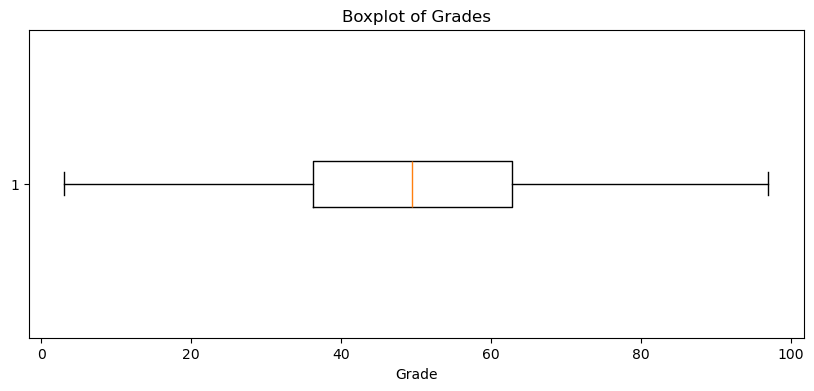

In [ ]:
# visualize the distribution of grades using a boxplot
grades = df_students.Grade

fig = plt.figure(figsize=(10, 4))

plt.boxplot(grades, vert=False)
plt.title('Boxplot of Grades')
plt.xlabel('Grade')

fig.show()

/var/folders/y3/wkpj6zv13tv6m566htln9m1h0000gn/T/ipykernel_20114/1790987501.py:9: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


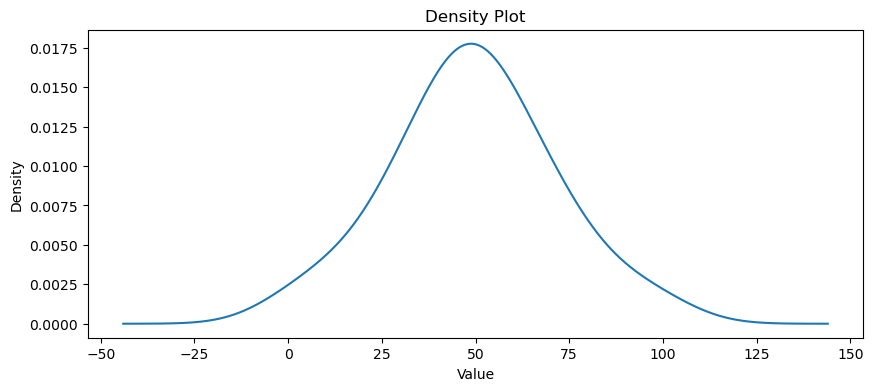

In [ ]:
# visualize the distribution of grades using a density plot
def show_density(data):
    fig = plt.figure(figsize=(10, 4))

    data.plot.density()
    
    plt.title('Density Plot')
    plt.xlabel('Value')
    plt.ylabel('Density')
    fig.show()

show_density(df_students.Grade)

/var/folders/y3/wkpj6zv13tv6m566htln9m1h0000gn/T/ipykernel_20114/1790987501.py:9: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


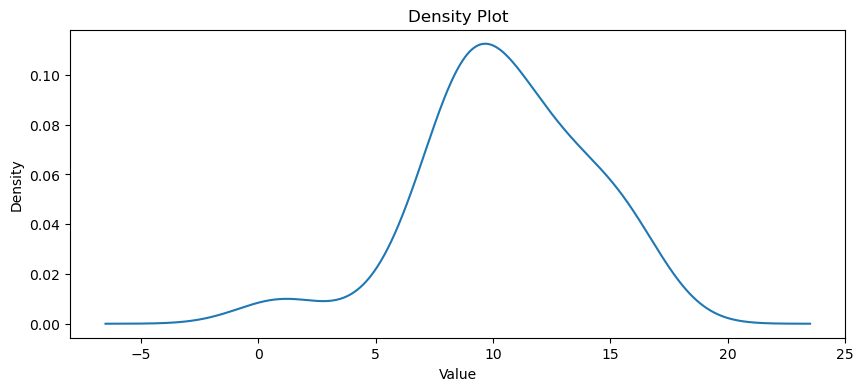

In [ ]:
# visualize the distribution of study hours using a density plot
show_density(df_students.StudyHours)

Min: 3.00
Max: 97.00
Mean: 49.18
Median: 49.50
Mode: 50.00


/var/folders/y3/wkpj6zv13tv6m566htln9m1h0000gn/T/ipykernel_20114/1871502273.py:31: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


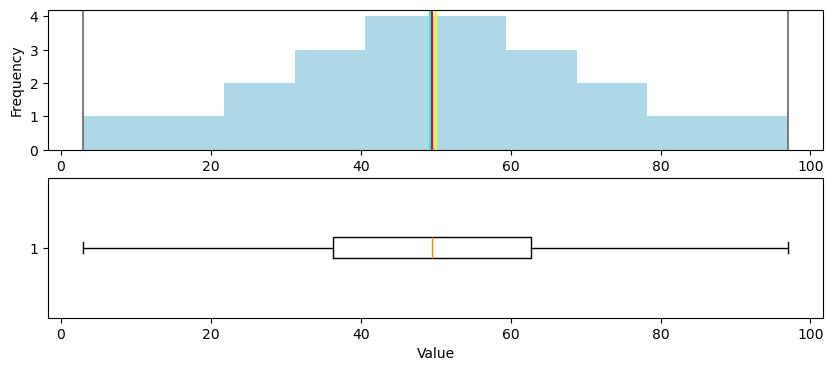

In [91]:
def show_distribution(data):
    min_val = data.min()
    max_val = data.max()
    mean_val = data.mean()
    med_val = data.median()
    mode_val = data.mode()[0]

    print(f'Min: {min_val:.2f}')
    print(f'Max: {max_val:.2f}')
    print(f'Mean: {mean_val:.2f}')
    print(f'Median: {med_val:.2f}')
    print(f'Mode: {mode_val:.2f}')


    fig, ax = plt.subplots(2, 1, figsize=(10, 4))

    # visualize the distribution of grades using a histogram
    ax[0].hist(data, color='lightblue')    
    ax[0].axvline(x=min_val, color='gray')
    ax[0].axvline(x=max_val, color='gray')
    ax[0].axvline(x=mean_val, color='cyan')
    ax[0].axvline(x=med_val, color='red')
    ax[0].axvline(x=mode_val, color='yellow')
    ax[0].set_xlabel('Value')
    ax[0].set_ylabel('Frequency')
    
    # visualize the distribution of grades using a boxplot
    ax[1].boxplot(data, vert=False)
    ax[1].set_xlabel('Value')

    fig.show()

show_distribution(df_students.Grade)

Min: 1.00
Max: 16.00
Mean: 10.52
Median: 10.00
Mode: 9.00


/var/folders/y3/wkpj6zv13tv6m566htln9m1h0000gn/T/ipykernel_20114/1871502273.py:31: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


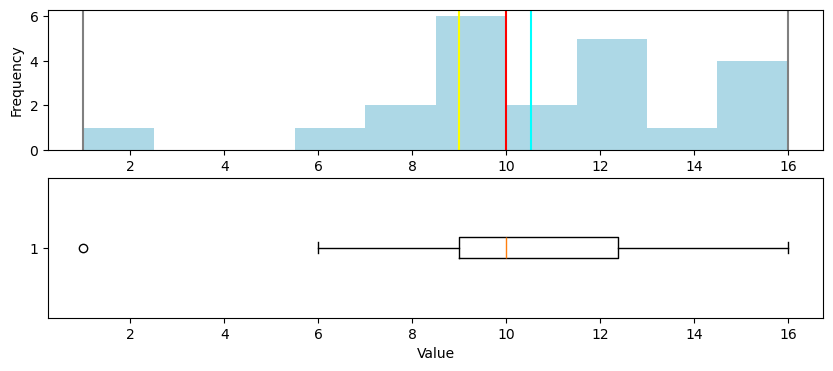

In [ ]:
# visualize the distribution of study hours using a histogram and a boxplot
show_distribution(df_students.StudyHours)

Min: 6.00
Max: 16.00
Mean: 10.98
Median: 10.00
Mode: 9.00


/var/folders/y3/wkpj6zv13tv6m566htln9m1h0000gn/T/ipykernel_20114/1871502273.py:31: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


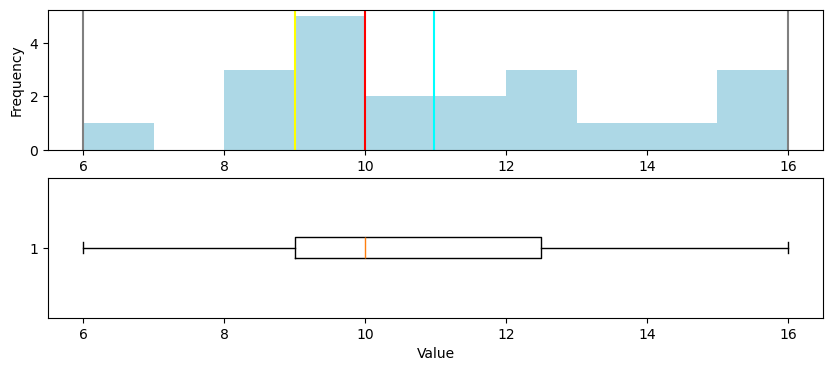

In [96]:
# visualize the distribution of study hours for students who study more than 1 hour per week (eliminating outliers)
col = df_students[df_students.StudyHours > 1][['StudyHours']]
show_distribution(col.StudyHours)

/var/folders/y3/wkpj6zv13tv6m566htln9m1h0000gn/T/ipykernel_20114/1790987501.py:9: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


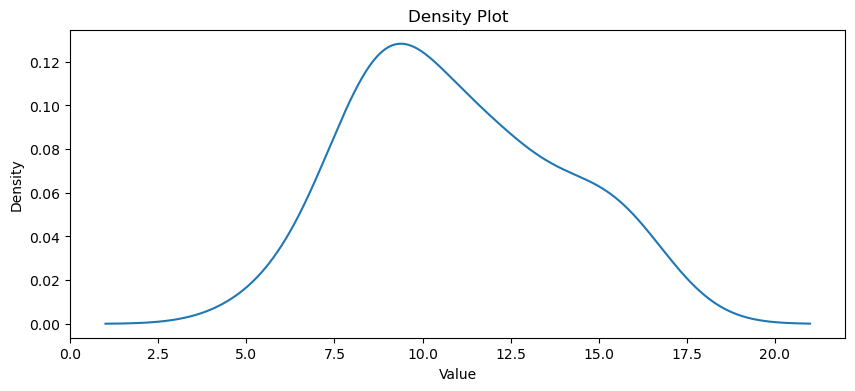

In [ ]:
# visualize the distribution of study hours for students who study more than 1 hour per week (eliminating outliers) using a density plot
show_density(col.StudyHours)

In [ ]:
# calculate the standard deviation of study hours
import math

mean = df_students.StudyHours.mean()
variance = 0

for hours in df_students.StudyHours:
    variance += (hours - mean) ** 2

variance = variance / len(df_students.StudyHours)
std = math.sqrt(variance)

print(f'Standard Deviation: {std:.2f}')


Variance: 11.61
Standard Deviation: 3.41


In [ ]:
# calculate the range, variance and standard deviation for both grades and study hours
for col_name in ['Grade', 'StudyHours']:
    col = df_students[col_name]
    rng = col.max() - col.min()
    var = col.var()
    std = col.std()
    print(f'{col_name} - Range: {rng:.2f}, Variance: {var:.2f}, Standard Deviation: {std:.2f}')


Grade - Range: 94.00, Variance: 472.54, Standard Deviation: 21.74
StudyHours - Range: 15.00, Variance: 12.16, Standard Deviation: 3.49


In [ ]:
# calculate the percentage of grades that fall within one standard deviation of the mean
print(f'68% of grades fall within one standard deviation of the mean: {df_students.Grade.mean() - df_students.Grade.std():.2f} to {df_students.Grade.mean() + df_students.Grade.std():.2f}')

68% of grades fall within one standard deviation of the mean: 27.44 to 70.92


In [110]:
df_students.describe()

,StudyHours,Grade
count,22.000000,22.000000
mean,10.522727,49.181818
std,3.487144,21.737912
min,1.000000,3.000000
25%,9.000000,36.250000
50%,10.000000,49.500000
75%,12.375000,62.750000
max,16.000000,97.000000


In [111]:
df_sample = df_students[df_students.StudyHours > 1]
df_sample

,Name,StudyHours,Grade,Passed
0,Dan,10.00,50.0,False
1,Joann,11.50,50.0,False
2,Pedro,9.00,47.0,False
3,Rosie,16.00,97.0,True
4,Ethan,9.25,49.0,False
6,Frederic,11.50,53.0,False
7,Jimmie,9.00,42.0,False
8,Rhonda,8.50,26.0,False
9,Giovanni,14.50,74.0,True
10,Francesca,15.50,82.0,True


<Axes: title={'center': 'StudyHours'}, xlabel='Passed'>

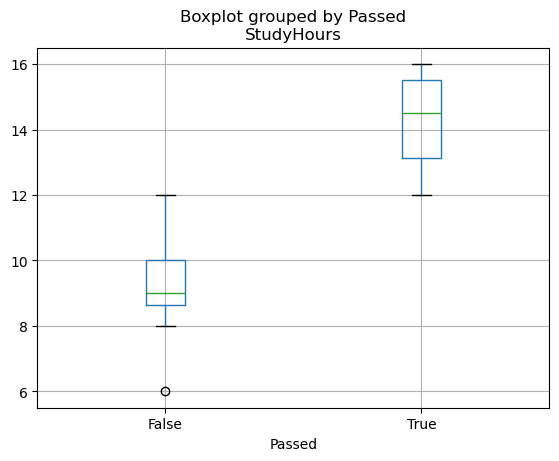

In [ ]:
# visualize the distribution of study hours for students who study more than 1 hour per week (eliminating outliers) using a boxplot
df_sample.boxplot(column='StudyHours', by='Passed')

<Axes: xlabel='Name'>

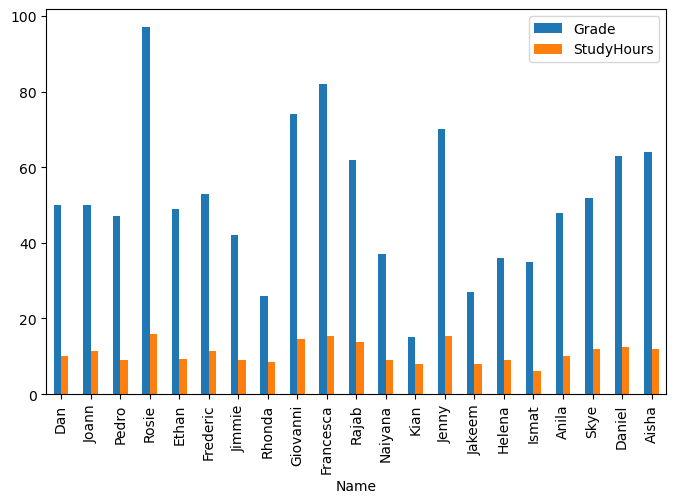

In [ ]:
# visualize the relationship between grades and study hours for students who study more than 1 hour per week (eliminating outliers) using a bar chart
df_sample.plot(x='Name', y=['Grade', 'StudyHours'], kind='bar', figsize=(8, 5))

<Axes: title={'center': 'Normalized Grades and Study Hours'}, xlabel='Name'>

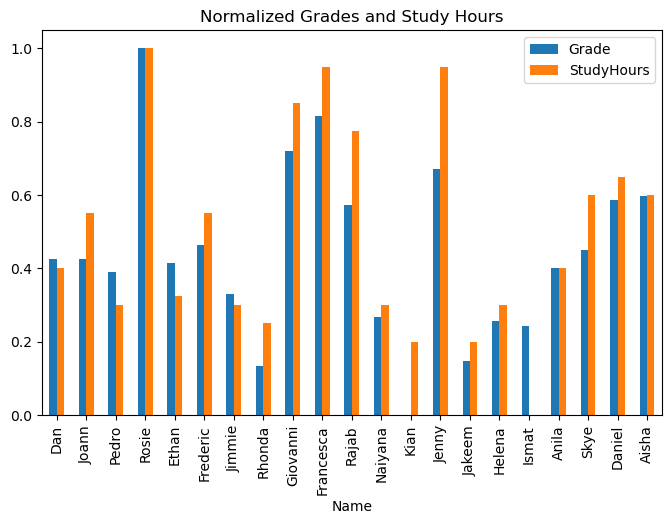

In [ ]:
# visualize the relationship between grades and study hours for students who study more than 1 hour per week (eliminating outliers) using a bar chart with normalized values
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

df_normalized = df_sample[['Name', 'Grade', 'StudyHours']].copy()
df_normalized[['Grade', 'StudyHours']] = scaler.fit_transform(df_normalized[['Grade', 'StudyHours']])
df_normalized.plot(x='Name', y=['Grade', 'StudyHours'], kind='bar', figsize=(8, 5), title='Normalized Grades and Study Hours')

In [ ]:
# calculate the correlation between grades and study hours for students who study more than 1 hour per week (eliminating outliers) using the normalized values
df_normalized.Grade.corr(df_normalized.StudyHours)

np.float64(0.9117666413789677)

<Axes: title={'center': 'Grades vs Study Hours'}, xlabel='StudyHours', ylabel='Grade'>

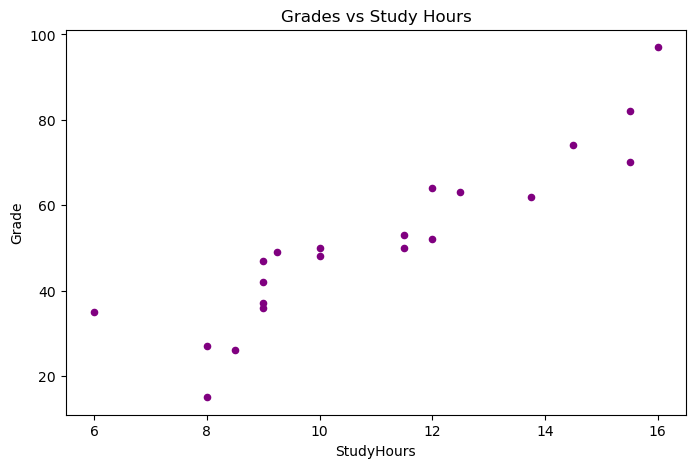

In [ ]:
# visualize the relationship between grades and study hours for students who study more than 1 hour per week (eliminating outliers) using a scatter plot
df_sample.plot.scatter(x='StudyHours', y='Grade', color='purple', figsize=(8, 5), title='Grades vs Study Hours')

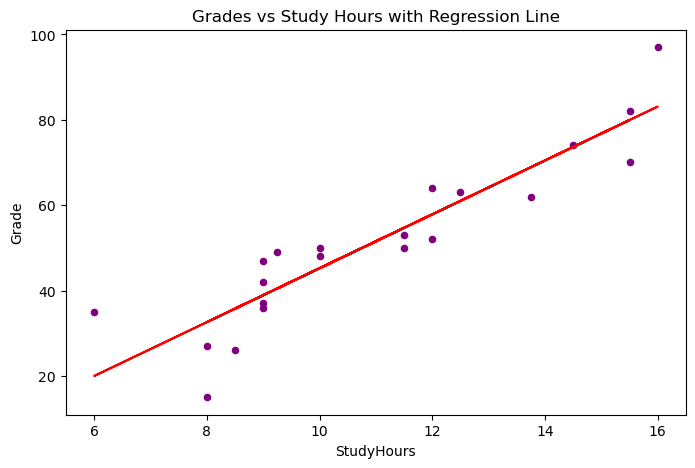

6.31342563379236 -17.91640993281615


In [123]:
# perform a linear regression to find the line of best fit for the relationship between grades and study hours for students who study more than 1 hour per week (eliminating outliers)
from scipy import stats

df_regression = df_sample[['StudyHours', 'Grade']].copy()
m, b, r, p, se = stats.linregress(df_regression.StudyHours, df_regression.Grade)

df_regression['fx'] = m * df_regression.StudyHours + b
df_regression['error'] = (df_regression.Grade - df_regression.fx) ** 2

df_regression.plot.scatter(x='StudyHours', y='Grade', color='purple', figsize=(8, 5), title='Grades vs Study Hours with Regression Line')
plt.plot(df_regression.StudyHours, df_regression.fx, color='red')
plt.show()

print(m, b)

In [ ]:
# use the line of best fit to predict the grade of a student who studies 18 hours per week
def predict_grade(study_hours):
    return m * study_hours + b

prediction = predict_grade(18)
prediction

np.float64(95.72525147544634)